# 📊 CareerLens AI — Phase 1: Exploratory Data Analysis & Dataset Audit

**Author**: Bassem Ramadan & CareerLens AI Team  
**Dataset Source**: [Hugging Face: BassemRamdan/data](https://huggingface.co/datasets/BassemRamdan/data)  

This notebook presents the definitive exploratory data analysis of the 2,484 raw resumes distributed across 24 professional career categories.


In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
print("Libraries successfully imported.")

Libraries successfully imported.


## 1. Dataset Loading & Stratified Splits Audit

In [2]:
meta_path = '../data/metadata.csv' if os.path.exists('../data/metadata.csv') else 'resume_metadata_split.csv'
meta_df = pd.read_csv(meta_path)

print(f"Total Resumes in Raw Dataset: {len(meta_df)}")
print(f"Number of Unique Categories: {meta_df['category'].nunique()}")
print("\nDataset Columns:", list(meta_df.columns))
display(meta_df.head(5))

Total Resumes in Raw Dataset: 2484
Number of Unique Categories: 24

Dataset Columns: ['relative_path', 'category', 'filename', 'split']


,relative_path,category,filename,split
0,SALES\15765660.pdf,SALES,15765660.pdf,train
1,CHEF\19007667.pdf,CHEF,19007667.pdf,train
2,CONSTRUCTION\20681037.pdf,CONSTRUCTION,20681037.pdf,train
3,AGRICULTURE\17312146.pdf,AGRICULTURE,17312146.pdf,train
4,TEACHER\24791126.pdf,TEACHER,24791126.pdf,train


In [3]:
# Inspect Split Stratification
split_counts = meta_df['split'].value_counts()
print("Split Distribution:")
for split_name, count in split_counts.items():
    pct = (count / len(meta_df)) * 100
    print(f"  - {split_name.capitalize()}: {count} resumes ({pct:.1f}%)")

Split Distribution:
  - Train: 1738 resumes (70.0%)
  - Val: 373 resumes (15.0%)
  - Test: 373 resumes (15.0%)


## 2. Category Distribution Across Categories

In [4]:
cat_counts = meta_df['category'].value_counts()
print("Category Counts Summary:")
print(f"  - Max resumes per category: {cat_counts.max()} ({cat_counts.idxmax()})")
print(f"  - Min resumes per category: {cat_counts.min()} ({cat_counts.idxmin()})")
print(f"  - Mean resumes per category: {cat_counts.mean():.1f}")
print("\nTop 10 Categories:\n", cat_counts.head(10))

Category Counts Summary:
  - Max resumes per category: 120 (INFORMATION-TECHNOLOGY)
  - Min resumes per category: 22 (BPO)
  - Mean resumes per category: 103.5

Top 10 Categories:
 category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ENGINEERING               118
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
CHEF                      118
FITNESS                   117
AVIATION                  117
SALES                     116
Name: count, dtype: int64


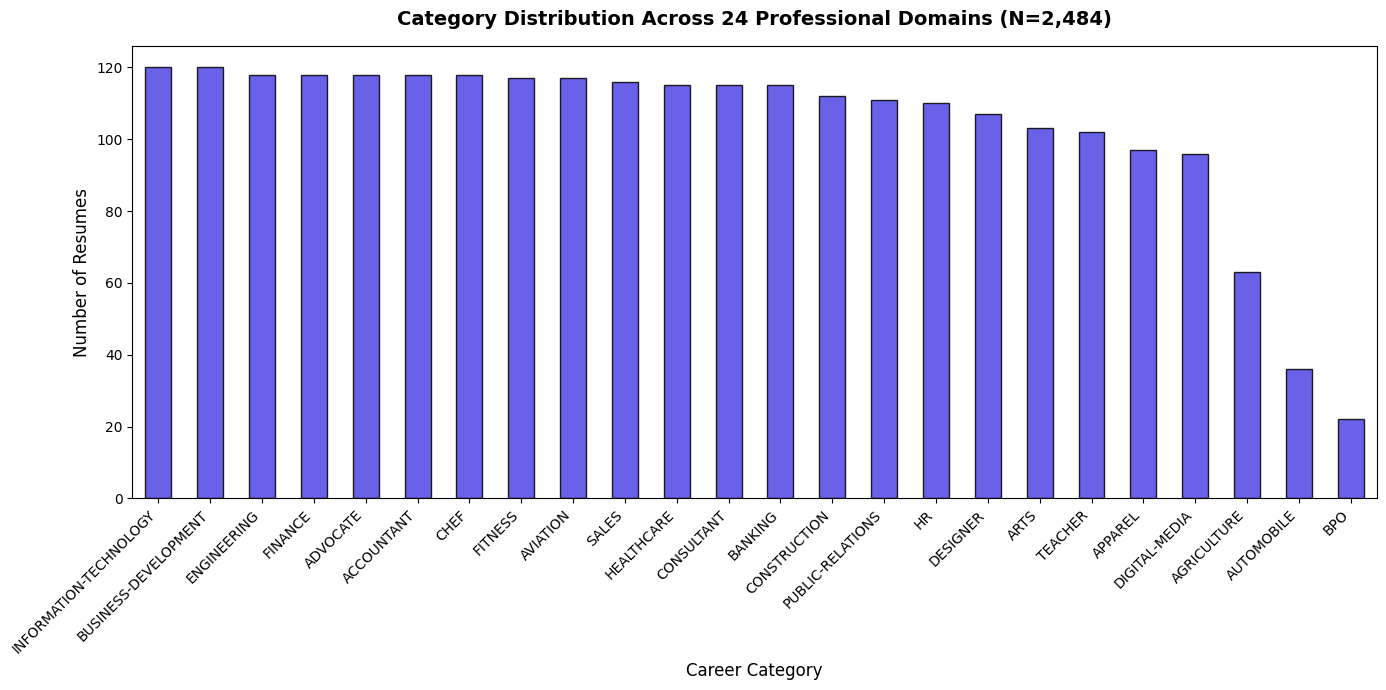

In [5]:
# Plot Category Distribution
plt.figure(figsize=(14, 7))
cat_counts.plot(kind='bar', color='#4F46E5', edgecolor='black', alpha=0.85)
plt.title('Category Distribution Across 24 Professional Domains (N=2,484)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Career Category', fontsize=12)
plt.ylabel('Number of Resumes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Text Length Statistics (Word & Character Counts)

In [6]:
proc_path = '../data/processed_resumes.csv' if os.path.exists('../data/processed_resumes.csv') else 'nlp_processed_resumes.csv'
proc_df = pd.read_csv(proc_path)

proc_df['char_count'] = proc_df['raw_clean_text'].astype(str).apply(len)
proc_df['word_count'] = proc_df['raw_clean_text'].astype(str).apply(lambda x: len(x.split()))

print("Text Statistics Summary:")
print(proc_df[['char_count', 'word_count']].describe().round(1))

Text Statistics Summary:
       char_count  word_count
count      2466.0      2466.0
mean       5904.7       809.1
std        2610.4       360.5
min         688.0       113.0
25%        4813.0       650.0
50%        5529.0       756.5
75%        6824.8       931.8
max       35064.0      5176.0


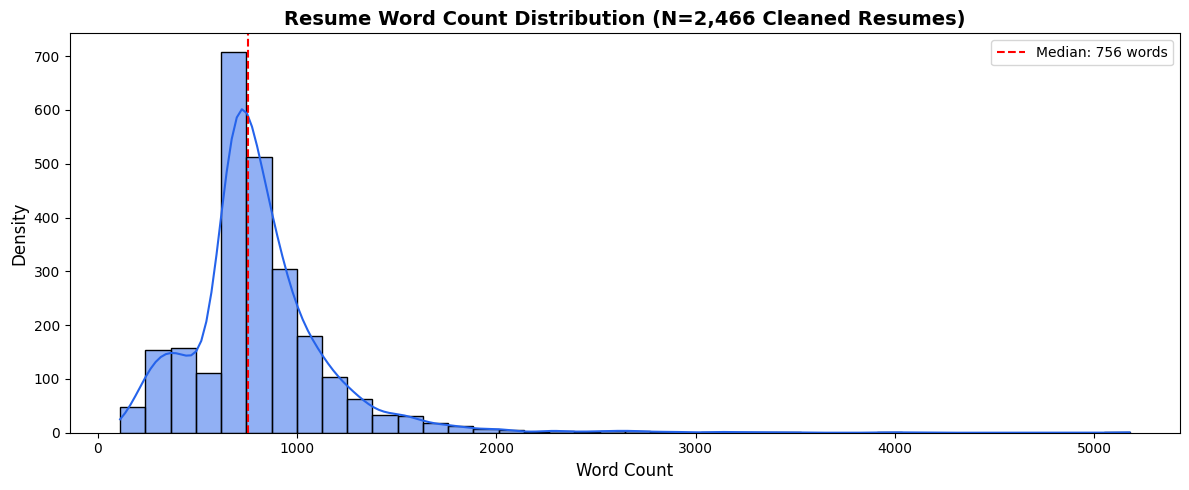

In [7]:
# Plot Text Word Count Distribution
plt.figure(figsize=(12, 5))
sns.histplot(proc_df['word_count'], bins=40, kde=True, color='#2563EB')
plt.axvline(proc_df['word_count'].median(), color='red', linestyle='--', label=f'Median: {proc_df["word_count"].median():.0f} words')
plt.title('Resume Word Count Distribution (N=2,466 Cleaned Resumes)', fontsize=14, fontweight='bold')
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Representative Domain Samples Inspection

In [8]:
sample_cats = ['INFORMATION-TECHNOLOGY', 'FINANCE', 'ENGINEERING']
for cat in sample_cats:
    sample = proc_df[proc_df['category'] == cat].iloc[0]
    print(f"=== Category: {cat} (ID: {sample['filename']}) ===")
    print(sample['raw_clean_text'][:350].strip() + "\n... [TRUNCATED] ...\n")

=== Category: INFORMATION-TECHNOLOGY (ID: 10089434.pdf) ===
INFORMATION TECHNOLOGY TECHNICIAN I Summary Versatile Systems Administrator possessing superior troubleshooting skills for networking issues, end user problems, and network security. Experienced in server management, systems analysis, and offering in-depth understanding of IT infrastructure areas. Detail-oriented, independent, and focused on taking
... [TRUNCATED] ...

=== Category: FINANCE (ID: 10549585.pdf) ===
FINANCE MANAGER/ OPERATIONS MANAGER Career Overview To obtain a full time position in Management Information Systems with emphasis on business analysis where I can demonstrate excellent leadership, business and team work skills to produce effective results. Qualifications Technical help desk experience Strong analytical skills Strong collaborative
... [TRUNCATED] ...

=== Category: ENGINEERING (ID: 10030015.pdf) ===
ENGINEERING LAB TECHNICIAN Career Focus My main objective in seeking employment with Triumph Actuation 